# Air Quality Analysis Pipeline
This notebook is a stage-wise orchestrator over modular `.py` files in `functions/`.

In [ ]:
# !pip install -r requirements.txt
# !python -m pip install 'tensorflow[and-cuda]'

In [ ]:
# import tensorflow as tf
# gpus = tf.config.list_physical_devices('GPU')
# if gpus:
#     print("GPU detected and available for TensorFlow.")
#     for gpu in gpus:
#         print(f"Name: {gpu.name}, Type: {gpu.device_type}")
# else:
#     print("No GPU available for TensorFlow, using CPU.")

No GPU available for TensorFlow, using CPU.


In [2]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from functions import (
    PipelineConfig,
    setup_environment,
    run_stage01,
    run_stage02,
    run_stage03,
    run_stage04,
    run_stage05,
)

config = PipelineConfig(
    base_dir=Path.cwd(),
    save_artifacts=False,  # set True to save stage outputs under ./artifacts
)
setup_environment(config)

print(f'Working directory: {config.base_dir}')
print(f'CSV exists: {config.csv_path.exists()}')


Working directory: d:\Air Quality Monitoring
CSV exists: True


## Stage 1: Load, Filter, Preprocess, and Describe

In [3]:
state = run_stage01(config)

print('Raw shape:', state.metrics['stage01_overview']['raw_shape'])
print('Clean shape:', state.metrics['stage01_overview']['clean_shape'])
print('Date range:', state.metrics['stage01_overview']['date_start'], 'to', state.metrics['stage01_overview']['date_end'])

print('AQI class distribution:')
print(state.metrics['stage01_overview']['aqi_class_distribution'])

print('Top missing columns (raw):')
display(state.metrics['quality_raw'].head(10))

print('Top missing columns (clean):')
display(state.metrics['quality_clean'].head(10))


Raw shape: (70464, 19)
Clean shape: (70463, 22)
Date range: 2012-11-01 01:00:00 to 2021-01-01 00:00:00
AQI class distribution:
AQI_class
Unhealthy         21847
Moderate          16733
Very Unhealthy    11057
USG               10422
Good               5688
Hazardous          4716
Name: count, dtype: int64
Top missing columns (raw):


,dtype,missing_count,missing_pct,n_unique
V Wind Speed,float64,61992,87.98,274
BP,float64,40285,57.17,2747
O3 8hr,float64,38879,55.18,3808
SO2,float64,35943,51.01,4932
NO2,float64,35296,50.09,4148
NO,float64,35148,49.88,7770
NOX,float64,34914,49.55,9240
O3,float64,34443,48.88,4127
CO 8hr,float64,34035,48.30,622
Temperature,float64,33622,47.72,3036


Top missing columns (clean):


,dtype,missing_count,missing_pct,n_unique
datetime,datetime64[us],0,0.0,70463
SO2,float64,0,0.0,23016
NO,float64,0,0.0,38252
NO2,float64,0,0.0,31305
NOX,float64,0,0.0,40973
CO,float64,0,0.0,25355
CO 8hr,float64,0,0.0,20336
O3,float64,0,0.0,31781
O3 8hr,float64,0,0.0,28458
PM2.5,float64,0,0.0,37712


## Stage 2: Machine Learning Classification

In [4]:
state = run_stage02(state, config)

print('Baseline model summary:')
display(state.metrics['stage02_summary'])

print('Logistic Regression report:')
print(state.metrics['stage02_baselines']['logistic_regression']['report'])

print('Random Forest report:')
print(state.metrics['stage02_baselines']['random_forest']['report'])

print('XGBoost same-time AQI:')
if 'report' in state.metrics['stage02_xgb_same_time']:
    print(state.metrics['stage02_xgb_same_time']['report'])
else:
    print(state.metrics['stage02_xgb_same_time'])

print('XGBoost future AQI (t+24):')
if 'report' in state.metrics['stage02_xgb_future']:
    print(state.metrics['stage02_xgb_future']['report'])
else:
    print(state.metrics['stage02_xgb_future'])


Baseline model summary:


,task,model,metric,value
0,AQI same-time,logistic_regression,macro_f1,0.787507
1,AQI same-time,random_forest,macro_f1,0.982024
2,AQI same-time,xgboost,macro_f1,0.988782
3,AQI t+24,xgboost,macro_f1,0.364663


Logistic Regression report:
                precision    recall  f1-score   support

          Good       0.87      0.64      0.73       591
     Hazardous       0.85      0.47      0.61       613
      Moderate       0.87      0.91      0.89      2423
           USG       0.74      0.89      0.81      1523
     Unhealthy       0.94      0.91      0.92      4215
Very Unhealthy       0.71      0.82      0.76      1205

      accuracy                           0.85     10570
     macro avg       0.83      0.77      0.79     10570
  weighted avg       0.86      0.85      0.85     10570

Random Forest report:
                precision    recall  f1-score   support

          Good       1.00      0.98      0.99       591
     Hazardous       1.00      0.90      0.95       613
      Moderate       0.99      1.00      0.99      2423
           USG       1.00      0.99      0.99      1523
     Unhealthy       1.00      1.00      1.00      4215
Very Unhealthy       0.95      1.00      0.97     

## Stage 3: Deep Learning Training and Results

,task,model,accuracy,macro_f1,weighted_f1
0,AQI same-time,cnn_cls,0.754601,0.243301,0.680411
1,AQI same-time,bilstm_cls,0.026771,0.040299,0.004636
2,AQI same-time,gru_cls,0.030117,0.022211,0.002034


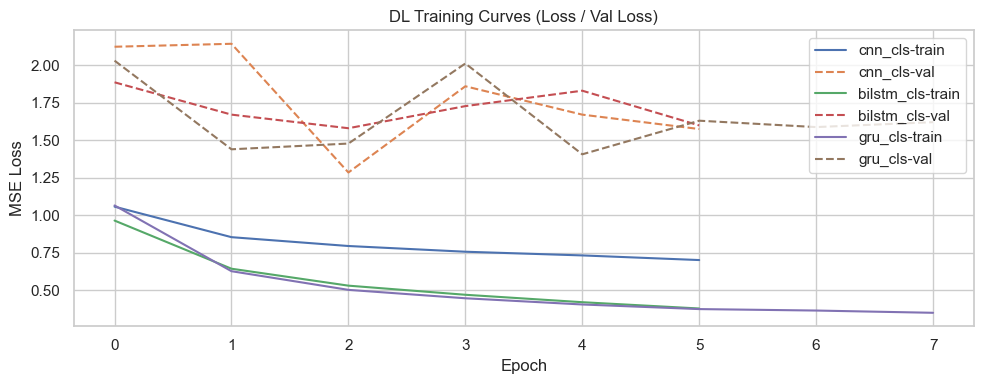

In [5]:
# from importlib import reload
# reload(run_stage03)

state = run_stage03(state, config)

if 'stage03_summary' in state.metrics:
    display(state.metrics['stage03_summary'])

    histories = state.metrics['stage03_histories']
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    for model_name, hist in histories.items():
        ax.plot(hist.get('loss', []), label=f'{model_name}-train')
        ax.plot(hist.get('val_loss', []), linestyle='--', label=f'{model_name}-val')
    ax.set_title('DL Training Curves (Loss / Val Loss)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(state.metrics.get('stage03_status', 'Stage 3 did not produce outputs.'))


## Stage 4: Time-Series Forecasting

,target,MAE,RMSE,model
0,PM2.5_t_plus_1,9.091140,16.822154,linear_regression
1,PM2.5_t_plus_2,14.371632,22.766272,linear_regression
2,PM2.5_t_plus_3,17.616570,26.525804,linear_regression
3,PM2.5_t_plus_4,19.053301,28.416866,linear_regression
4,PM2.5_t_plus_5,19.553072,29.275060,linear_regression
5,PM2.5_t_plus_6,19.976489,30.029914,linear_regression
6,PM2.5_t_plus_7,20.244520,30.539848,linear_regression
7,PM2.5_t_plus_8,20.356527,30.855421,linear_regression
8,PM2.5_t_plus_9,20.115356,30.905565,linear_regression
9,PM2.5_t_plus_10,20.036224,30.981564,linear_regression


Average forecasting errors by model:


,model,MAE,RMSE
0,linear_regression,12.567588,19.935406
1,ridge_recursive,10.949833,24.403853


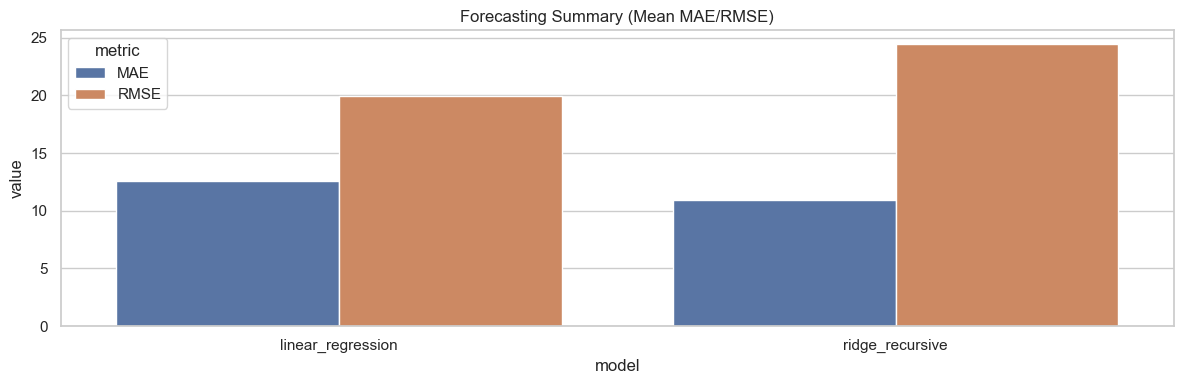

In [6]:
state = run_stage04(state, config)

compare_metrics = state.metrics['stage04_compare_metrics'].copy()
display(compare_metrics.head(20))

summary_fc = compare_metrics.groupby('model', as_index=False)[['MAE', 'RMSE']].mean().sort_values('RMSE')
print('Average forecasting errors by model:')
display(summary_fc)

plt.figure(figsize=(12, 4))
sns.barplot(data=summary_fc.melt(id_vars='model', var_name='metric', value_name='value'), x='model', y='value', hue='metric')
plt.title('Forecasting Summary (Mean MAE/RMSE)')
plt.tight_layout()
plt.show()


## Stage 5: Statistical Analysis

In [7]:
state = run_stage05(state, config)

if 'stage05_results' in state.metrics:
    display(state.metrics['stage05_results'])
else:
    print(state.metrics.get('stage05_status', 'Stage 5 did not produce outputs.'))


,test,statistic,p_value
0,ADF (PM2.5),-9.173608,2.352196e-15
1,KPSS (PM2.5),0.531444,3.458472e-02
2,Kruskal-Wallis PM2.5 by hour,2384.324675,0.000000e+00
3,Spearman PM2.5 vs RH,-0.078810,1.791542e-97


## Unified Summary

,Task,Model,Metric,Value
0,AQI same-time,logistic_regression,macro_f1,0.787507
1,AQI same-time,random_forest,macro_f1,0.982024
2,AQI same-time,xgboost,macro_f1,0.988782
5,AQI same-time,cnn_cls,Macro F1,0.243301
8,AQI same-time,bilstm_cls,Macro F1,0.040299
11,AQI same-time,gru_cls,Macro F1,0.022211


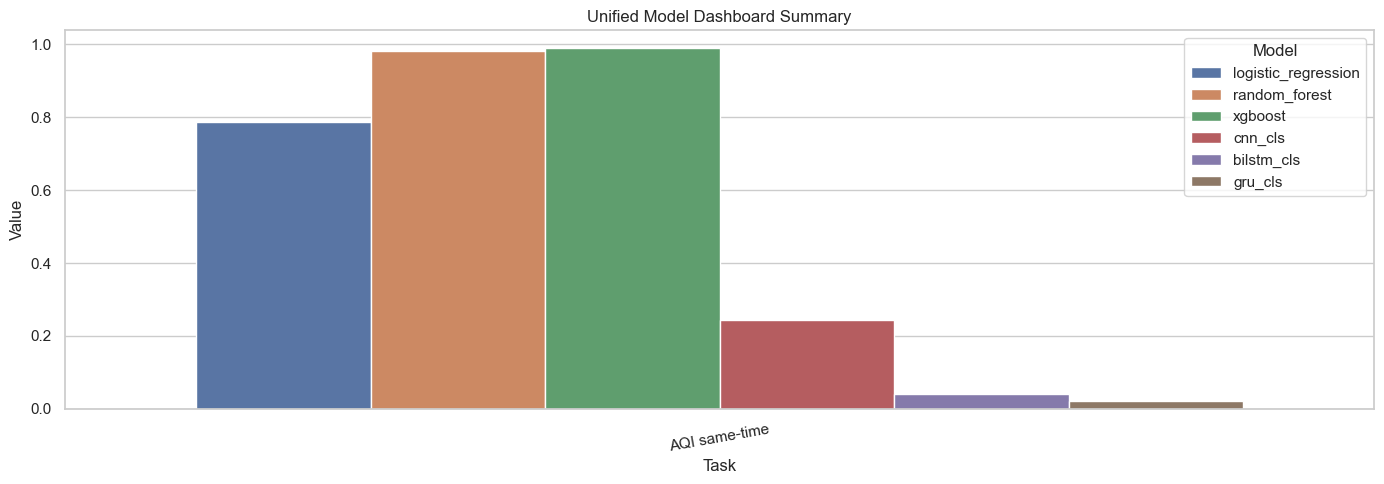

In [9]:
rows = []

if 'stage02_summary' in state.metrics:
    for _, r in state.metrics['stage02_summary'].iterrows():
        rows.append({'Task': r['task'], 'Model': r['model'], 'Metric': r['metric'], 'Value': r['value']})

if 'stage03_summary' in state.metrics:
    for _, r in state.metrics['stage03_summary'].iterrows():
        rows.append({'Task': r['task'], 'Model': r['model'], 'Metric': 'Accuracy', 'Value': r['accuracy']})
        rows.append({'Task': r['task'], 'Model': r['model'], 'Metric': 'Macro F1', 'Value': r['macro_f1']})
        rows.append({'Task': r['task'], 'Model': r['model'], 'Metric': 'Weighted F1', 'Value': r['weighted_f1']})

if 'stage04_compare_metrics' in state.metrics:
    for model_name, g in state.metrics['stage04_compare_metrics'].groupby('model'):
        rows.append({'Task': 'Time-Series Forecasting', 'Model': model_name, 'Metric': 'mean_rmse', 'Value': float(g['RMSE'].mean())})
        rows.append({'Task': 'Time-Series Forecasting', 'Model': model_name, 'Metric': 'mean_mae', 'Value': float(g['MAE'].mean())})

summary_df = pd.DataFrame(rows)
filtered_df = summary_df[summary_df['Task'] == 'AQI same-time']   
filtered_df = filtered_df[filtered_df['Metric'].isin(['macro_f1', 'Macro F1'])]

display(filtered_df)

if not summary_df.empty:
    # only take AZI same-time forecasting results for better comparison
    filtered_df = summary_df[summary_df['Task'] == 'AQI same-time']   
    filtered_df = filtered_df[filtered_df['Metric'].isin(['macro_f1', 'Macro F1'])]

    plt.figure(figsize=(14, 5))
    sns.barplot(data=filtered_df, x='Task', y='Value', hue='Model', ci=None)
    plt.title('Unified Model Dashboard Summary')
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()